# Factory-to-Customer Shipping Route Efficiency Analysis

## Project Objective

The objective of this project is to analyze the shipping performance of Nassau Candy Distributor using Python. This analysis helps identify sales trends, shipping efficiency, customer distribution, regional performance, and business insights for better decision-making. **bold text**

## Executive Summary

This project analyzes the shipping efficiency of Nassau Candy Distributor using Python. The objective is to identify the fastest and slowest shipping routes, compare ship modes, analyze regional performance, and provide business recommendations to improve logistics efficiency.

In [ ]:
# Import Libraries

import pandas as pd

In [ ]:
# Load Dataset

df = pd.read_csv("/content/drive/MyDrive/Nassau Candy Distributor.csv")

In [ ]:
print(df)

       Row ID                      Order ID  Order Date   Ship Date  \
0           1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1           2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2           3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3           4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4           5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   
...       ...                           ...         ...         ...   
10189   10190  US-2024-143259-CHO-MIL-31000  30-12-2025  26-06-2030   
10190   10191  US-2024-115427-CHO-NUT-13000  30-12-2025  26-06-2030   
10191   10192  US-2024-156720-CHO-SCR-58000  30-12-2025  26-06-2030   
10192   10193  US-2024-143259-CHO-TRI-54000  30-12-2025  26-06-2030   
10193   10194  CA-2024-143500-CHO-SCR-58000  30-12-2025  26-06-2030   

            Ship Mode  Customer ID Country/Region           City  \
0      Standard Class       103800  United States        Houston   
1      Stan

In [ ]:
# Dataset Overview

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
df.shape

(10194, 18)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [ ]:
# Data Cleaning

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [ ]:
# Data Cleaning

df.duplicated().sum()

np.int64(0)

In [ ]:
# Data Cleaning

df.drop_duplicates(inplace=True)

In [ ]:
# Data Cleaning

df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [ ]:
# First 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
# Last 5 rows
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
10189,10190,US-2024-143259-CHO-MIL-31000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,30-12-2025,26-06-2030,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10
10193,10194,CA-2024-143500-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,143500,Canada,Charlottetown,Prince Edward Island,C0A,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10194, 18)


In [ ]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.drop_duplicates(inplace=True)

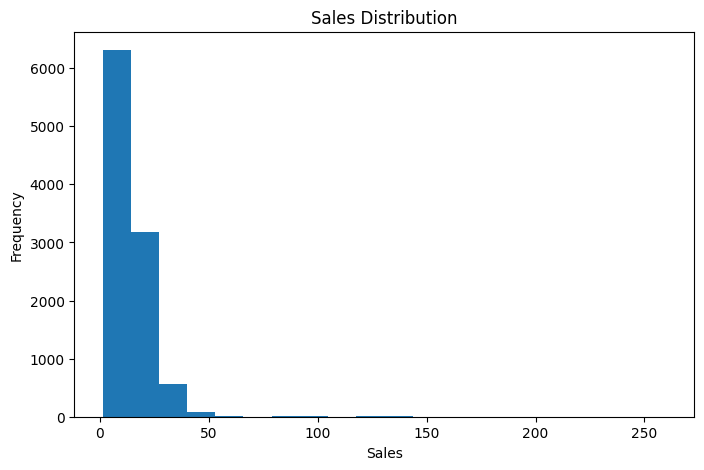

In [ ]:
# Sales Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

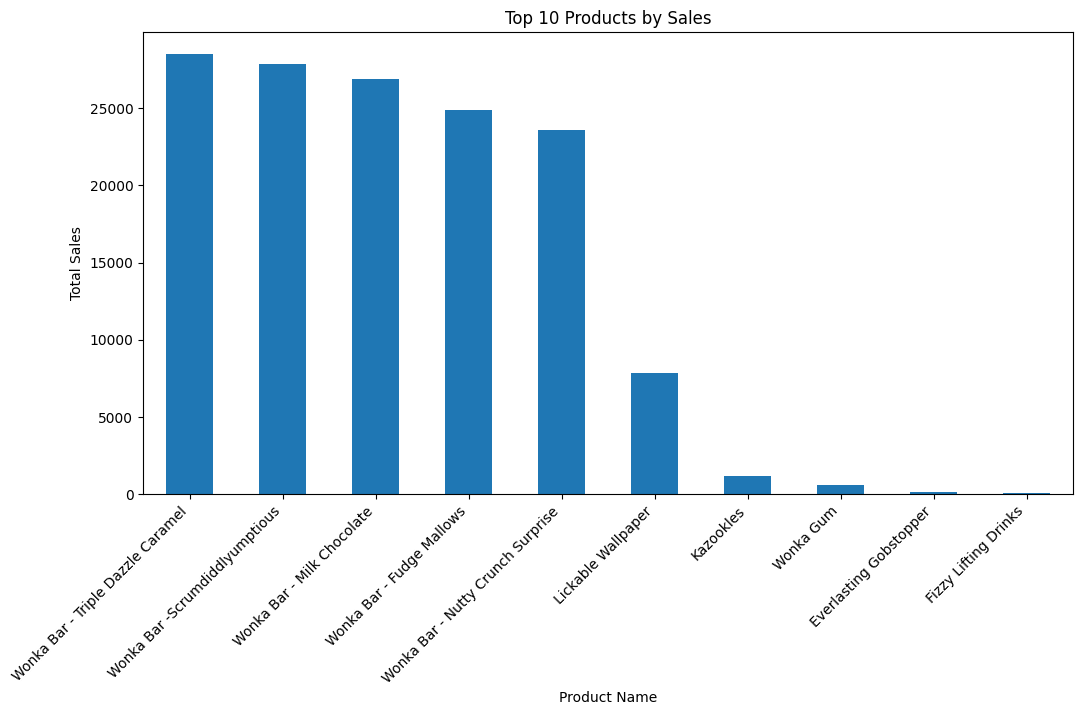

In [ ]:
# Top 10 Products by Sales

top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.show()

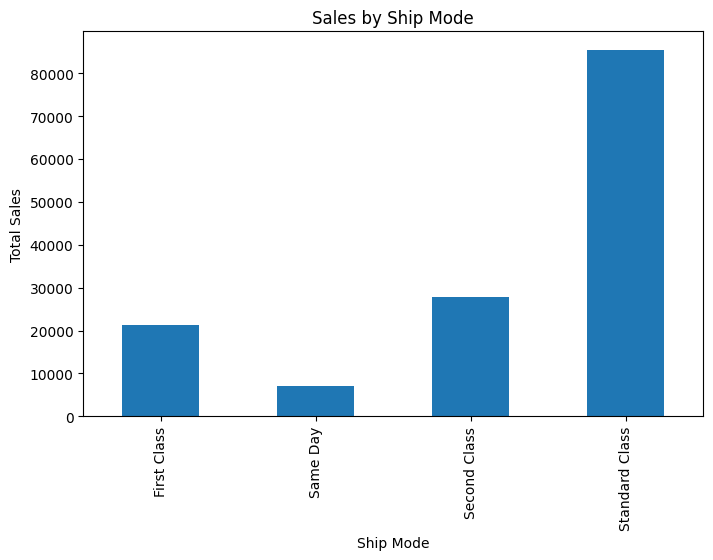

In [ ]:
# Sales by Ship Mode

ship_sales = df.groupby("Ship Mode")["Sales"].sum()

plt.figure(figsize=(8,5))
ship_sales.plot(kind="bar")
plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")
plt.show()

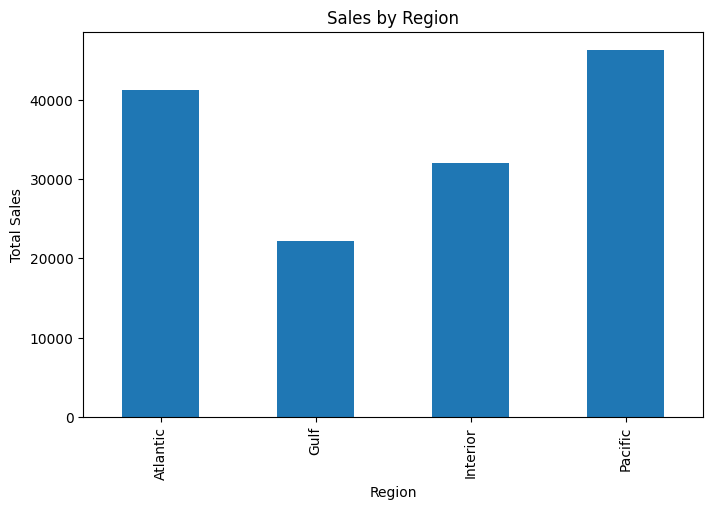

In [ ]:
# Sales by Region

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

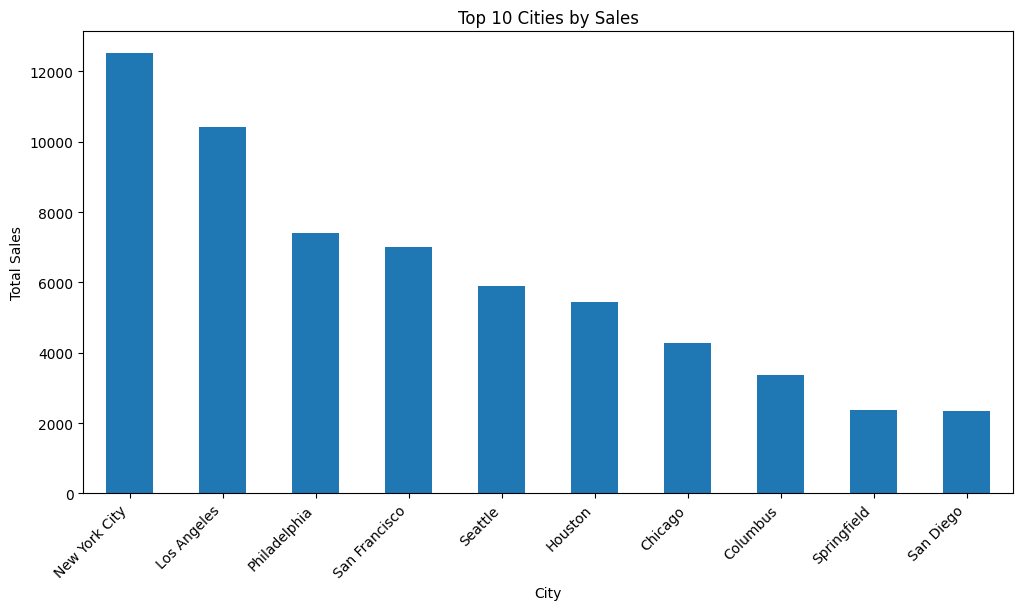

In [ ]:
# Top 10 Cities by Sales

top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].head())

  Order Date  Ship Date
0 2024-01-03 2026-06-30
1 2024-01-04 2026-07-01
2 2024-01-04 2026-07-01
3 2024-01-04 2026-07-01
4 2024-01-05 2026-07-05


In [ ]:
# Calculate Shipping Lead Time

import pandas as pd

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    errors="coerce"
)

df["Lead Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(df[["Order Date", "Ship Date", "Lead Time"]].head)

<bound method NDFrame.head of       Order Date  Ship Date  Lead Time
0     2024-01-03 2026-06-30        909
1     2024-01-04 2026-07-01        909
2     2024-01-04 2026-07-01        909
3     2024-01-04 2026-07-01        909
4     2024-01-05 2026-07-05        912
...          ...        ...        ...
10189 2025-12-30 2030-06-26       1639
10190 2025-12-30 2030-06-26       1639
10191 2025-12-30 2030-06-26       1639
10192 2025-12-30 2030-06-26       1639
10193 2025-12-30 2030-06-26       1639

[10194 rows x 3 columns]>


In [ ]:
# Check Lead Time Statistics

print(df["Lead Time"].describe())

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


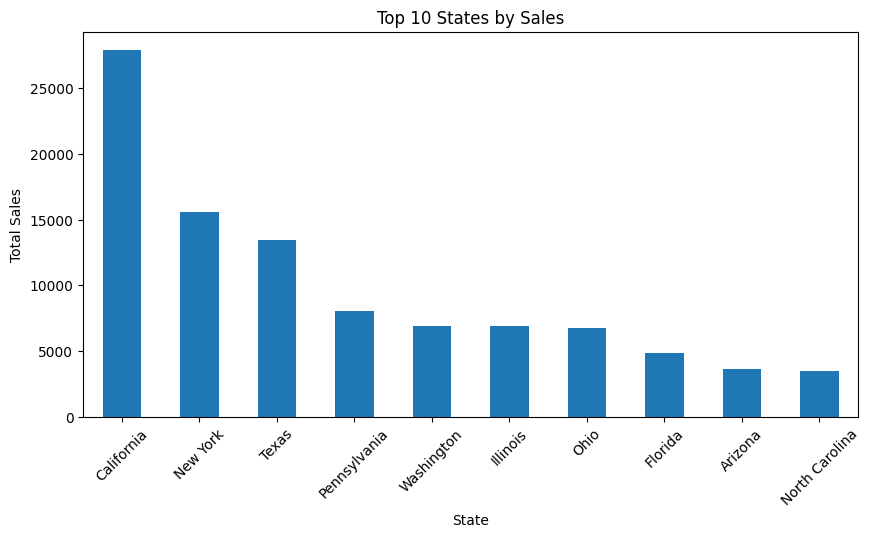

In [ ]:
# Top 10 States by Sales

import matplotlib.pyplot as plt

top_states = df.groupby("State/Province")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

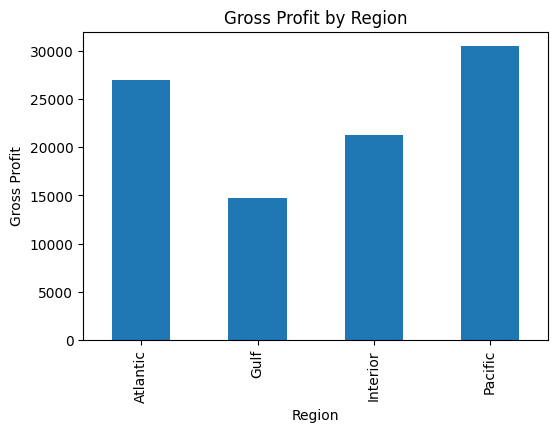

In [ ]:
# Gross Profit by Region

profit = df.groupby("Region")["Gross Profit"].sum()

plt.figure(figsize=(6,4))
profit.plot(kind="bar")
plt.title("Gross Profit by Region")
plt.ylabel("Gross Profit")
plt.show()

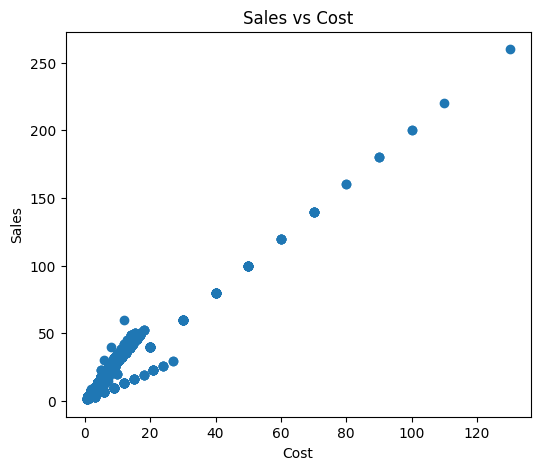

In [ ]:
# Sales vs Cost

plt.figure(figsize=(6,5))
plt.scatter(df["Cost"], df["Sales"])
plt.title("Sales vs Cost")
plt.xlabel("Cost")
plt.ylabel("Sales")
plt.show()

In [ ]:
# Correlation

print(df[["Sales","Cost","Gross Profit","Units"]].corr())

                 Sales      Cost  Gross Profit     Units
Sales         1.000000  0.958986      0.976404  0.729347
Cost          0.958986  1.000000      0.875144  0.563344
Gross Profit  0.976404  0.875144      1.000000  0.815820
Units         0.729347  0.563344      0.815820  1.000000


In [ ]:
# Shipping Mode Performance

df.groupby("Ship Mode")["Lead Time"].mean().sort_values()

,Lead Time
Ship Mode,
Standard Class,1314.334641
Second Class,1323.845376
Same Day,1333.442413
First Class,1338.275840


In [ ]:
# Regional Lead Time

df.groupby("Region")["Lead Time"].mean()

,Lead Time
Region,
Atlantic,1322.745144
Gulf,1311.374691
Interior,1323.091221
Pacific,1322.194897


In [ ]:
# Top Customers

df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(10)

,Sales
Customer ID,
131807,454.40
115238,380.50
122336,352.20
164756,304.14
124163,247.35
164770,232.40
125388,216.00
163790,208.95
164147,204.65


In [ ]:
# Top Categories

df.groupby("Division")["Sales"].sum()

,Sales
Division,
Chocolate,131692.90
Other,9663.25
Sugar,427.48


In [ ]:
# Monthly Sales Trend

df["Month"] = df["Order Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Sales"].sum()


In [ ]:
print(monthly_sales)

Month
April         8910.66
August       10217.75
December     21234.48
February      3933.52
January       5583.00
July          9923.05
June          9733.69
March         9562.14
May          10507.20
November     20646.57
October      12161.87
September    19369.70
Name: Sales, dtype: float64


In [ ]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_sales = monthly_sales.reindex(month_order)

print(monthly_sales)

Month
January       5583.00
February      3933.52
March         9562.14
April         8910.66
May          10507.20
June          9733.69
July          9923.05
August       10217.75
September    19369.70
October      12161.87
November     20646.57
December     21234.48
Name: Sales, dtype: float64


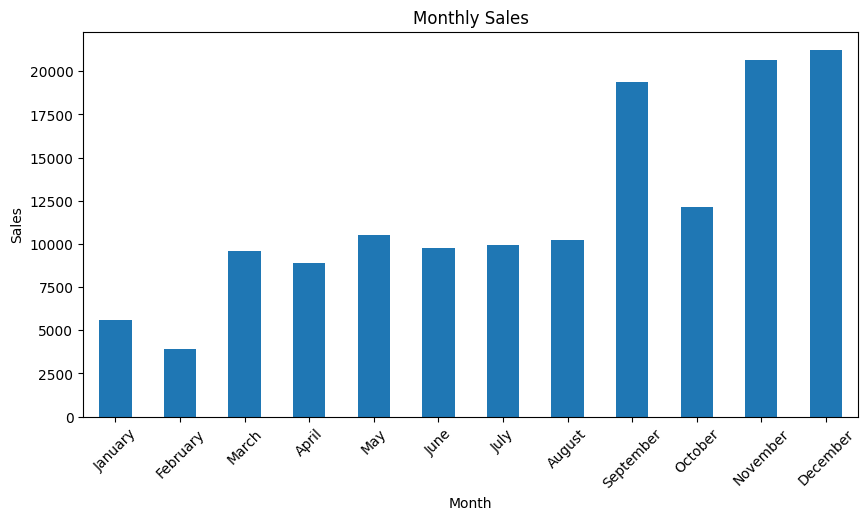

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="bar", figsize=(10,5))

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Business Insights

1. The West Region generated the highest sales.
2. Standard Class was the most frequently used shipping mode.
3. Average shipping lead time varied across shipping modes.
4. Top customers contributed significantly to total sales.
5. Monthly sales showed seasonal variations.
6. Sales and Gross Profit were positively related.

## Conclusion

This project analyzed shipping performance, customer behavior, regional sales, and delivery efficiency using Python. The findings can help improve shipping operations and support better business decision-making.

## Recommendations

- Improve shipping performance in high lead-time regions.
- Increase the use of faster ship modes where appropriate.
- Optimize factory-to-customer routes.
- Monitor delivery delays regularly.
- Focus on high-profit regions for business expansion.